# Notebook 06 — Property Value Regression + Ablation Study

**Purpose:** Predict Brooklyn building assessed values using ML regression. The project's **central methodological question** is tested here via an ablation study:

> *Does adding unsupervised clustering labels (from Notebook 05) to raw features improve regression performance?*

**Three feature sets compared:**
- **Set A**: raw + engineered features (no cluster info) — the baseline
- **Set B**: A + `cluster_X` one-hot (6 categorical cluster indicators)
- **Set C**: A + `dist_to_cluster_*` (6 continuous distance-to-centroid features)

**Four model families per set:**
1. Mean predictor (null baseline, R² ≈ 0)
2. Linear Regression (median imputation, multicollinearity baseline)
3. Random Forest (non-linear baseline, handles NaN natively)
4. XGBoost (gradient boosting, light hyperparameter tuning)

**Total: 12 evaluated configurations** under **spatial cross-validation** (1 km × 1 km grid GroupKFold, 5 folds) to prevent spatial leakage.

**Inputs:** `data/processed/brooklyn_clustered.parquet` (from Notebook 05)

**Outputs:**
- `outputs/models/best_regression_model.joblib` — best (model, feature_set) configuration
- `outputs/figures/regression/*.png` — ablation table, predicted-vs-actual, residual maps
- Ablation results table (markdown) for the final report

**Author:** Delfin Aksu

## 1. Setup

In [1]:
import warnings
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold, RandomizedSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.spines.top'] = False

In [2]:
PROJECT_ROOT = Path('..').resolve()
PROCESSED_DATA_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures' / 'regression'
MODEL_DIR = PROJECT_ROOT / 'outputs' / 'models'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
N_CV_SPLITS = 5

pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda v: f'{v:,.4f}')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'FIGURE_DIR:   {FIGURE_DIR}')
print(f'MODEL_DIR:    {MODEL_DIR}')

PROJECT_ROOT: C:\Users\Delfin AKSU\Desktop\urban-building-ml
FIGURE_DIR:   C:\Users\Delfin AKSU\Desktop\urban-building-ml\outputs\figures\regression
MODEL_DIR:    C:\Users\Delfin AKSU\Desktop\urban-building-ml\outputs\models


## 2. Load the Clustered Dataset

In [3]:
clustered_path = PROCESSED_DATA_DIR / 'brooklyn_clustered.parquet'
assert clustered_path.exists(), f'Missing input: {clustered_path}. Run Notebook 05 first.'

df = pd.read_parquet(clustered_path)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'File size: {clustered_path.stat().st_size / 1024**2:.1f} MB')

# Verify cluster columns exist
expected_cluster_cols = [f'cluster_{i}' for i in range(6)] + [f'dist_to_cluster_{i}' for i in range(6)] + ['cluster_id', 'cluster_name']
missing = [c for c in expected_cluster_cols if c not in df.columns]
assert not missing, f'Missing cluster columns: {missing}'
print(f'\nAll cluster columns present.')
print(f'Cluster sizes: {df["cluster_id"].value_counts().sort_index().to_dict()}')

Loaded: 265,507 rows x 59 columns
File size: 32.6 MB

All cluster columns present.
Cluster sizes: {0: 59528, 1: 77833, 2: 8802, 3: 10180, 4: 109156, 5: 8}


### 2.1 Define target (log-transformed)

In [4]:
# Target: log1p(assesstot). Section 8 of Notebook 02 documented why this transform is necessary.
df['log_assesstot'] = np.log1p(df['assesstot'])

print(f'Target range: log_assesstot from {df["log_assesstot"].min():.2f} ({np.expm1(df["log_assesstot"].min()):,.0f}) to {df["log_assesstot"].max():.2f} ({np.expm1(df["log_assesstot"].max()):,.0f})')
print(f'Median log_assesstot: {df["log_assesstot"].median():.2f} (≈ ${np.expm1(df["log_assesstot"].median()):,.0f})')

Target range: log_assesstot from 5.76 (316) to 20.86 (1,142,662,050)
Median log_assesstot: 11.44 (≈ $93,240)


## 3. Define Ablation Feature Sets

Critical decision: which features go into each set, and which are excluded as **target leakage**.

**Always-excluded (target leakage):**
- `assesstot`, `log_assesstot` — the target itself
- `assessland` — Spearman ρ = +0.62 with target (DOF computes both together)
- `exempttot` — derived from assessment process
- `is_extreme_value` — derived directly from `assesstot`

**Always-excluded (identifiers / non-features):**
- `bbl`, `block`, `lot`, `address`, `borough`, `zipcode`, `cd`, `cd_label`
- `cluster_name`, `build_decade`, `landuse_name`
- `firm07_flag` (use binary `in_flood_zone` instead)
- `latitude`, `longitude` (used for spatial CV grouping only — NOT as features)

### 3.1 Build Set A (raw + engineered, no cluster info)

In [5]:
BASE_FEATURES = [
    # PLUTO physical
    'lotarea', 'bldgarea', 'comarea', 'resarea',
    'numbldgs', 'numfloors', 'unitsres', 'unitstotal',
    # Age
    'yearbuilt', 'yearalter1', 'building_age',
    # Misc PLUTO
    'builtfar',
    # Subway
    'nearest_subway_dist', 'subway_count_500m', 'subway_count_1000m',
    # POI density
    'cafe_count_500m', 'restaurant_count_500m', 'school_count_500m',
    'park_count_500m', 'supermarket_count_500m', 'convenience_count_500m',
    'poi_count_500m_total',
    # Engineered
    'far', 'unit_density', 'commercial_unit_ratio', 'commercial_area_ratio',
    'in_flood_zone',
]

# Land use one-hot (categorical typology)
landuse_dummies = pd.get_dummies(df['landuse'], prefix='lu', dummy_na=False).astype(int)
df = pd.concat([df, landuse_dummies], axis=1)
LANDUSE_FEATURES = landuse_dummies.columns.tolist()

SET_A = BASE_FEATURES + LANDUSE_FEATURES
print(f'Set A: {len(SET_A)} features ({len(BASE_FEATURES)} numeric + {len(LANDUSE_FEATURES)} landuse one-hot)')

Set A: 38 features (27 numeric + 11 landuse one-hot)


### 3.2 Build Set B (A + cluster_X one-hot)

In [6]:
CLUSTER_ONEHOT = [c for c in df.columns if c.startswith('cluster_') and c not in ['cluster_id', 'cluster_name']]
SET_B = SET_A + CLUSTER_ONEHOT
print(f'Set B: {len(SET_B)} features (Set A + {len(CLUSTER_ONEHOT)} cluster one-hot)')
print(f'Cluster one-hot columns: {CLUSTER_ONEHOT}')

Set B: 44 features (Set A + 6 cluster one-hot)
Cluster one-hot columns: ['cluster_0', 'cluster_1', 'cluster_2', 'cluster_3', 'cluster_4', 'cluster_5']


### 3.3 Build Set C (A + dist_to_cluster_*)

In [7]:
DIST_FEATURES = [c for c in df.columns if c.startswith('dist_to_cluster_')]
SET_C = SET_A + DIST_FEATURES
print(f'Set C: {len(SET_C)} features (Set A + {len(DIST_FEATURES)} distance features)')
print(f'Distance columns: {DIST_FEATURES}')

Set C: 44 features (Set A + 6 distance features)
Distance columns: ['dist_to_cluster_0', 'dist_to_cluster_1', 'dist_to_cluster_2', 'dist_to_cluster_3', 'dist_to_cluster_4', 'dist_to_cluster_5']


### 3.4 Feature set summary

In [8]:
FEATURE_SETS = {'A': SET_A, 'B': SET_B, 'C': SET_C}
summary = pd.DataFrame({
    'set': list(FEATURE_SETS.keys()),
    'description': ['raw + engineered (no cluster)', 'A + cluster_X one-hot', 'A + dist_to_cluster_*'],
    'n_features': [len(s) for s in FEATURE_SETS.values()],
})
summary

,set,description,n_features
0,A,raw + engineered (no cluster),38
1,B,A + cluster_X one-hot,44
2,C,A + dist_to_cluster_*,44


## 4. Spatial Cross-Validation Setup

**Why spatial CV?** Brooklyn buildings are not independent — neighbouring buildings share features (subway distance, POI density, urban typology). A naive random `train_test_split` puts a building's neighbours in both train and test sets, causing severe spatial leakage and overstated test performance.

**Our solution:** Bin Brooklyn into a 1 km × 1 km grid. Each building gets a `grid_id`. `GroupKFold` ensures buildings in the same grid cell are kept together — either all in train or all in test.

**Approximation:** 1 km ≈ 0.009 degrees latitude and 0.012 degrees longitude in Brooklyn.

### 4.1 Build the 1km × 1km grid

In [9]:
# Grid cell size: ~0.009 degrees lat, ~0.012 degrees lon ≈ 1 km each side at Brooklyn's latitude
GRID_LAT_STEP = 0.009
GRID_LON_STEP = 0.012

df['grid_lat'] = (df['latitude'] / GRID_LAT_STEP).astype(int)
df['grid_lon'] = (df['longitude'] / GRID_LON_STEP).astype(int)
df['grid_id'] = df['grid_lat'].astype(str) + '_' + df['grid_lon'].astype(str)

n_grids = df['grid_id'].nunique()
print(f'Total grid cells covering Brooklyn: {n_grids}')
print(f'Median buildings per grid cell: {df["grid_id"].value_counts().median():.0f}')
print(f'Largest grid cell: {df["grid_id"].value_counts().max()} buildings')
print(f'Smallest grid cell: {df["grid_id"].value_counts().min()} buildings')

Total grid cells covering Brooklyn: 204
Median buildings per grid cell: 1328
Largest grid cell: 3114 buildings
Smallest grid cell: 1 buildings


### 4.2 Visualise the grid

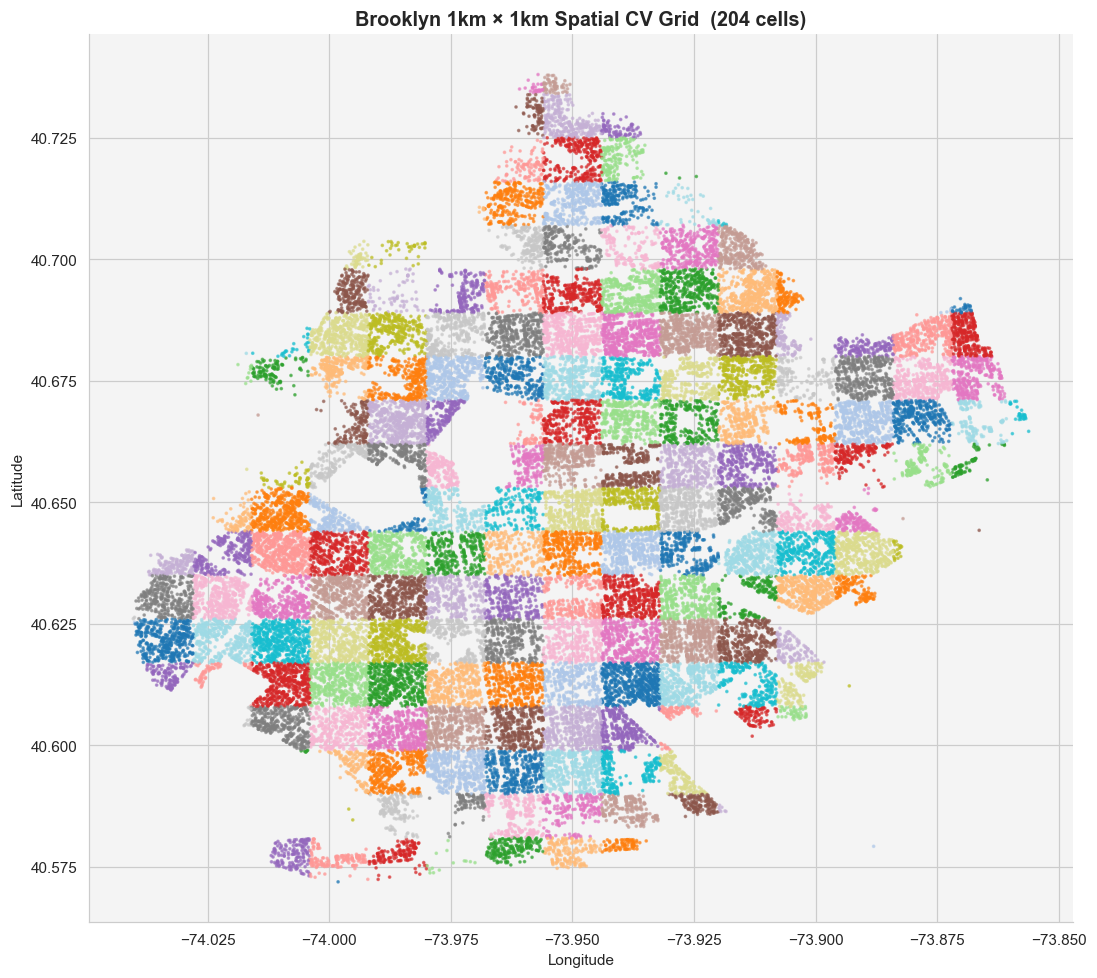

In [10]:
fig, ax = plt.subplots(figsize=(11, 9))
# Sample for plot speed
rng = np.random.default_rng(seed=RANDOM_SEED)
sample = df.loc[rng.choice(df.index, size=50_000, replace=False)]

# Color by grid_id (recycling colors is fine — only the boundary visualisation matters)
sample['_grid_color'] = pd.Categorical(sample['grid_id']).codes % 20
ax.scatter(sample['longitude'], sample['latitude'], c=sample['_grid_color'], cmap='tab20', s=2, alpha=0.6)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title(f'Brooklyn 1km × 1km Spatial CV Grid  ({n_grids} cells)', fontsize=13, fontweight='bold')
ax.set_aspect('equal'); ax.set_facecolor('#f4f4f4')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '06_spatial_cv_grid.png')
plt.show()

### 4.3 Configure GroupKFold

In [11]:
y = df['log_assesstot'].values
groups = df['grid_id'].values

cv = GroupKFold(n_splits=N_CV_SPLITS)
print(f'GroupKFold with {N_CV_SPLITS} splits configured')
print(f'Total buildings: {len(y):,}')
print(f'Grid groups:     {len(np.unique(groups))}')

# Preview fold sizes
X_dummy = df[SET_A].values
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X_dummy, y, groups)):
    print(f'  Fold {fold_idx+1}: train={len(train_idx):>7,}  test={len(test_idx):>7,}  test_grids={df.iloc[test_idx]["grid_id"].nunique()}')

GroupKFold with 5 splits configured
Total buildings: 265,507
Grid groups:     204
  Fold 1: train=212,405  test= 53,102  test_grids=41
  Fold 2: train=212,405  test= 53,102  test_grids=42
  Fold 3: train=212,406  test= 53,101  test_grids=41
  Fold 4: train=212,406  test= 53,101  test_grids=40
  Fold 5: train=212,406  test= 53,101  test_grids=40


## 5. Null Baseline — Mean Predictor

Before any real model, we establish the floor: a constant predictor that always outputs the training-set mean of `log_assesstot`. Its R² is 0 by construction (it explains none of the variance). Every other model must beat this.

In [12]:
def evaluate_with_spatial_cv(model, X, y, groups, model_name, feature_set_name):
    """Run spatial GroupKFold CV and return mean RMSE/MAE/R2 across folds."""
    cv_iter = GroupKFold(n_splits=N_CV_SPLITS).split(X, y, groups)
    rmses, maes, r2s = [], [], []
    for fold_idx, (train_idx, test_idx) in enumerate(cv_iter):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        rmses.append(np.sqrt(mean_squared_error(y_te, y_pred)))
        maes.append(mean_absolute_error(y_te, y_pred))
        r2s.append(r2_score(y_te, y_pred))
    return {'model': model_name, 'feature_set': feature_set_name,
            'rmse_mean': np.mean(rmses), 'rmse_std': np.std(rmses),
            'mae_mean': np.mean(maes), 'mae_std': np.std(maes),
            'r2_mean': np.mean(r2s), 'r2_std': np.std(r2s)}

from sklearn.dummy import DummyRegressor

results = []  # we will accumulate all evaluations here

t0 = time.time()
X_set_a = df[SET_A].fillna(df[SET_A].median()).values
null_result = evaluate_with_spatial_cv(
    DummyRegressor(strategy='mean'),
    X_set_a, y, groups,
    model_name='Null (mean)', feature_set_name='—',
)
print(f'Null baseline complete in {time.time()-t0:.1f}s')
print(f'  RMSE: {null_result["rmse_mean"]:.4f} ± {null_result["rmse_std"]:.4f}')
print(f'  MAE : {null_result["mae_mean"]:.4f} ± {null_result["mae_std"]:.4f}')
print(f'  R²  : {null_result["r2_mean"]:.4f} ± {null_result["r2_std"]:.4f}  (should be ≈ 0)')
results.append(null_result)

Null baseline complete in 0.6s
  RMSE: 1.1140 ± 0.0464
  MAE : 0.8598 ± 0.0470
  R²  : -0.0162 ± 0.0208  (should be ≈ 0)


## 6. Linear Regression Ablation (Ridge)

We use **Ridge regression** (L2-regularised linear) instead of plain OLS because:
- Some feature pairs are nearly collinear (`builtfar` ↔ `far`, `unitstotal` ↔ `unitsres`, dist_to_cluster components)
- Ridge handles multicollinearity gracefully without us having to manually drop columns
- Provides a fair linear baseline for the ablation

**Pre-processing**: median imputation for NaN (sklearn's Ridge cannot handle NaN natively).

In [13]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

def make_ridge():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('scale',  StandardScaler()),
        ('ridge',  Ridge(alpha=1.0, random_state=RANDOM_SEED)),
    ])

t0 = time.time()
for set_name, feat_list in FEATURE_SETS.items():
    X = df[feat_list].values
    r = evaluate_with_spatial_cv(make_ridge(), X, y, groups,
                                  model_name='Ridge', feature_set_name=set_name)
    results.append(r)
    print(f'Ridge / Set {set_name}: RMSE={r["rmse_mean"]:.4f}  MAE={r["mae_mean"]:.4f}  R²={r["r2_mean"]:.4f}')
print(f'\nRidge ablation complete in {time.time()-t0:.1f}s')

Ridge / Set A: RMSE=0.6778  MAE=0.4583  R²=0.6137
Ridge / Set B: RMSE=0.5942  MAE=0.4182  R²=0.7070
Ridge / Set C: RMSE=0.4839  MAE=0.3484  R²=0.8060

Ridge ablation complete in 16.7s


## 7. Random Forest Ablation

Random Forest is a non-linear baseline that:
- Handles NaN natively (no imputation needed)
- Captures feature interactions without manual specification
- Is robust to feature scaling

We use `n_estimators=200`, `n_jobs=-1` for speed. The bottleneck is the 5-fold × 3-set = 15 fits on ~210K training rows each.

In [14]:
from sklearn.ensemble import RandomForestRegressor

def make_rf():
    return Pipeline([
        ('impute', SimpleImputer(strategy='median')),
        ('rf', RandomForestRegressor(
            n_estimators=200, max_depth=None, min_samples_leaf=5,
            n_jobs=-1, random_state=RANDOM_SEED,
        )),
    ])

t0 = time.time()
for set_name, feat_list in FEATURE_SETS.items():
    X = df[feat_list].values
    r = evaluate_with_spatial_cv(make_rf(), X, y, groups,
                                  model_name='Random Forest', feature_set_name=set_name)
    results.append(r)
    print(f'RF / Set {set_name}: RMSE={r["rmse_mean"]:.4f}  MAE={r["mae_mean"]:.4f}  R²={r["r2_mean"]:.4f}  ({time.time()-t0:.0f}s elapsed)')
print(f'\nRF ablation complete in {time.time()-t0:.1f}s')

RF / Set A: RMSE=0.2830  MAE=0.1998  R²=0.9342  (424s elapsed)
RF / Set B: RMSE=0.2821  MAE=0.1988  R²=0.9346  (883s elapsed)
RF / Set C: RMSE=0.2788  MAE=0.1956  R²=0.9362  (1588s elapsed)

RF ablation complete in 1588.0s


## 8. XGBoost Ablation

XGBoost typically outperforms Random Forest on tabular data thanks to gradient boosting and built-in regularisation. We use **moderate** hyperparameters (not a full grid search — that would take hours):
- `n_estimators=400`
- `max_depth=6`
- `learning_rate=0.08`
- `subsample=0.85`, `colsample_bytree=0.85`
- `tree_method='hist'` (fast histogram-based splits)

XGBoost handles NaN natively as well. No imputation, no scaling required.

In [15]:
import xgboost as xgb

def make_xgb():
    return xgb.XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.85,
        colsample_bytree=0.85,
        tree_method='hist',
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbosity=0,
    )

t0 = time.time()
for set_name, feat_list in FEATURE_SETS.items():
    X = df[feat_list].values.astype(np.float32)
    r = evaluate_with_spatial_cv(make_xgb(), X, y, groups,
                                  model_name='XGBoost', feature_set_name=set_name)
    results.append(r)
    print(f'XGBoost / Set {set_name}: RMSE={r["rmse_mean"]:.4f}  MAE={r["mae_mean"]:.4f}  R²={r["r2_mean"]:.4f}  ({time.time()-t0:.0f}s elapsed)')
print(f'\nXGBoost ablation complete in {time.time()-t0:.1f}s')

XGBoost / Set A: RMSE=0.2727  MAE=0.1978  R²=0.9389  (25s elapsed)
XGBoost / Set B: RMSE=0.2721  MAE=0.1973  R²=0.9392  (54s elapsed)
XGBoost / Set C: RMSE=0.2670  MAE=0.1924  R²=0.9415  (83s elapsed)

XGBoost ablation complete in 82.5s


## 9. Ablation Results — The Central Finding

The table below is **the project's key methodological result**. For each (model, feature_set) combination we report mean ± std across 5 spatial CV folds.

**The decisive comparison:** within each model family (Ridge, RF, XGBoost), does Set B or Set C beat Set A?
- If yes → adding cluster information **improves regression** → the hybrid (unsupervised → supervised) pipeline adds value.
- If no  → the regression already captures everything the clustering knew → cluster labels are redundant.

Either outcome is a valid finding for the report.

In [16]:
results_df = pd.DataFrame(results)
results_df['summary'] = results_df.apply(
    lambda r: f"RMSE {r['rmse_mean']:.4f}±{r['rmse_std']:.4f}  |  MAE {r['mae_mean']:.4f}±{r['mae_std']:.4f}  |  R² {r['r2_mean']:.4f}±{r['r2_std']:.4f}",
    axis=1
)

# Pivot to compare feature sets within each model
pivot = results_df.pivot_table(index='model', columns='feature_set', values='r2_mean', sort=False)
pivot = pivot[['—', 'A', 'B', 'C']] if '—' in pivot.columns else pivot
print('R² across model × feature set:')
print(pivot.round(4))
print('\nFull results:')
print(results_df[['model', 'feature_set', 'rmse_mean', 'mae_mean', 'r2_mean']].round(4).to_string(index=False))

R² across model × feature set:
feature_set         —      A      B      C
model                                     
Null (mean)   -0.0162    NaN    NaN    NaN
Ridge             NaN 0.6137 0.7070 0.8060
Random Forest     NaN 0.9342 0.9346 0.9362
XGBoost           NaN 0.9389 0.9392 0.9415

Full results:
        model feature_set  rmse_mean  mae_mean  r2_mean
  Null (mean)           —     1.1140    0.8598  -0.0162
        Ridge           A     0.6778    0.4583   0.6137
        Ridge           B     0.5942    0.4182   0.7070
        Ridge           C     0.4839    0.3484   0.8060
Random Forest           A     0.2830    0.1998   0.9342
Random Forest           B     0.2821    0.1988   0.9346
Random Forest           C     0.2788    0.1956   0.9362
      XGBoost           A     0.2727    0.1978   0.9389
      XGBoost           B     0.2721    0.1973   0.9392
      XGBoost           C     0.2670    0.1924   0.9415


### 9.1 Visual comparison — R² by model and feature set

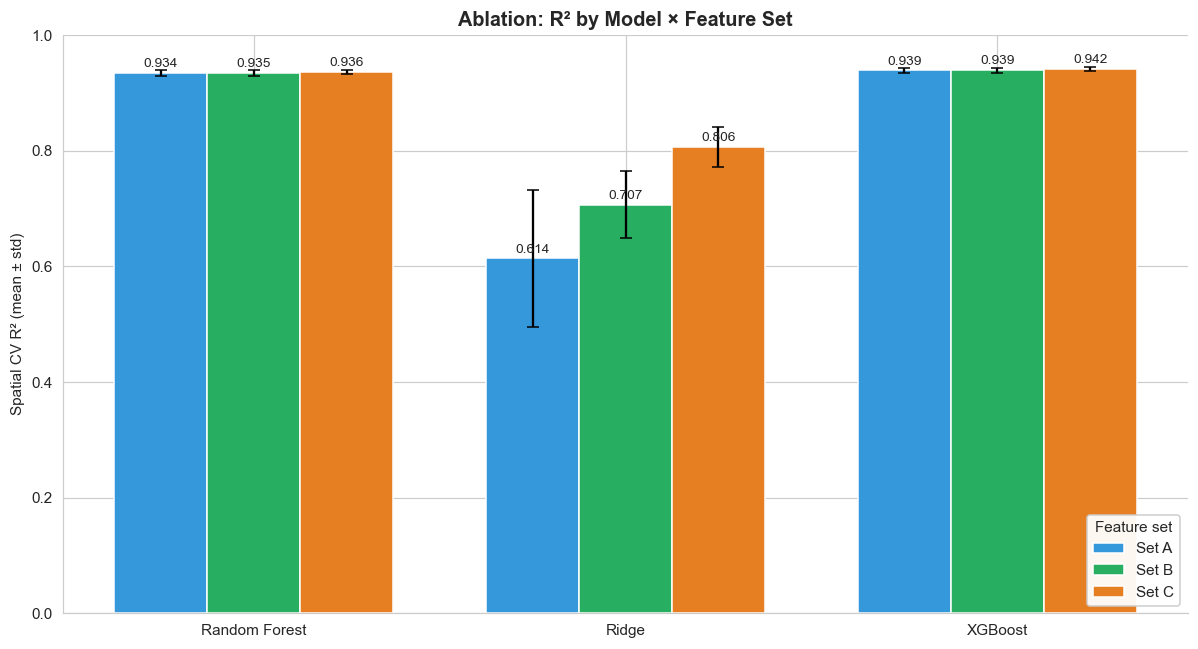

In [17]:
real_models = results_df[results_df['model'] != 'Null (mean)']
fig, ax = plt.subplots(figsize=(11, 6))

x = np.arange(real_models['model'].nunique())
width = 0.25
set_colors = {'A': '#3498db', 'B': '#27ae60', 'C': '#e67e22'}

for i, set_name in enumerate(['A', 'B', 'C']):
    subset = real_models[real_models['feature_set'] == set_name].sort_values('model')
    pos = x + (i - 1) * width
    bars = ax.bar(pos, subset['r2_mean'], width,
                   yerr=subset['r2_std'], capsize=4,
                   color=set_colors[set_name], edgecolor='white',
                   label=f'Set {set_name}')
    for b, v in zip(bars, subset['r2_mean']):
        ax.text(b.get_x() + b.get_width()/2, v + 0.005, f'{v:.3f}',
                ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(sorted(real_models['model'].unique()))
ax.set_ylabel('Spatial CV R² (mean ± std)')
ax.set_title('Ablation: R² by Model × Feature Set', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(1.0, real_models['r2_mean'].max() + 0.05))
ax.axhline(0, color='black', linewidth=0.6)
ax.legend(title='Feature set', loc='lower right', framealpha=0.95)
plt.tight_layout()
plt.savefig(FIGURE_DIR / '06_ablation_r2.png')
plt.show()

### 9.2 Identify best model

In [18]:
real_results = results_df[results_df['model'] != 'Null (mean)']
best_idx = real_results['r2_mean'].idxmax()
best_row = real_results.loc[best_idx]
print(f'BEST: {best_row["model"]} on Set {best_row["feature_set"]}')
print(f'   RMSE: {best_row["rmse_mean"]:.4f} ± {best_row["rmse_std"]:.4f}')
print(f'   MAE : {best_row["mae_mean"]:.4f} ± {best_row["mae_std"]:.4f}')
print(f'   R²  : {best_row["r2_mean"]:.4f} ± {best_row["r2_std"]:.4f}')

# Cluster lift per model: best of (B, C) vs A
print('\nCluster lift summary (Set A R² vs best of B/C):')
for model_name in real_results['model'].unique():
    sub = real_results[real_results['model'] == model_name]
    if 'A' not in sub['feature_set'].values:
        continue
    r2_a = sub[sub['feature_set'] == 'A']['r2_mean'].iloc[0]
    bc = sub[sub['feature_set'].isin(['B', 'C'])]
    if len(bc) == 0:
        continue
    best_bc_set = bc.loc[bc['r2_mean'].idxmax(), 'feature_set']
    r2_bc = bc['r2_mean'].max()
    lift_pct = (r2_bc - r2_a) / max(abs(r2_a), 1e-6) * 100
    print(f'  {model_name:<14s}: A R²={r2_a:.4f}  → best B/C ({best_bc_set}) R²={r2_bc:.4f}  '
          f'(lift = {r2_bc - r2_a:+.4f}, {lift_pct:+.2f}%)')

BEST: XGBoost on Set C
   RMSE: 0.2670 ± 0.0096
   MAE : 0.1924 ± 0.0069
   R²  : 0.9415 ± 0.0032

Cluster lift summary (Set A R² vs best of B/C):
  Ridge         : A R²=0.6137  → best B/C (C) R²=0.8060  (lift = +0.1923, +31.33%)
  Random Forest : A R²=0.9342  → best B/C (C) R²=0.9362  (lift = +0.0020, +0.22%)
  XGBoost       : A R²=0.9389  → best B/C (C) R²=0.9415  (lift = +0.0026, +0.28%)


## 10. Refit Best Model on Full Data + Save

Refit the winning (model, feature_set) on **all 265,507 buildings** (not 4/5 CV folds) — this is the production-ready model for SHAP analysis in Notebook 07. The CV metrics in §9 remain our honest performance estimates.

In [19]:
# Re-create the winning model and refit on the entire dataset
best_model_name = best_row['model']
best_set_name = best_row['feature_set']
best_feats = FEATURE_SETS[best_set_name]

if best_model_name == 'Ridge':
    final_model = make_ridge()
elif best_model_name == 'Random Forest':
    final_model = make_rf()
elif best_model_name == 'XGBoost':
    final_model = make_xgb()

X_best = df[best_feats].values
if best_model_name == 'XGBoost':
    X_best = X_best.astype(np.float32)

print(f'Refitting {best_model_name} on Set {best_set_name} ({X_best.shape}) ...')
t0 = time.time()
final_model.fit(X_best, y)
print(f'Done in {time.time()-t0:.1f}s')

# Persist
joblib.dump({
    'model': final_model,
    'feature_list': best_feats,
    'feature_set': best_set_name,
    'model_name': best_model_name,
    'cv_r2_mean': best_row['r2_mean'],
    'cv_rmse_mean': best_row['rmse_mean'],
    'cv_mae_mean': best_row['mae_mean'],
    'random_seed': RANDOM_SEED,
}, MODEL_DIR / 'best_regression_model.joblib')

joblib.dump(results_df, MODEL_DIR / 'ablation_results.joblib')
print(f'Saved: best_regression_model.joblib  +  ablation_results.joblib')

Refitting XGBoost on Set C ((265507, 44)) ...
Done in 7.1s
Saved: best_regression_model.joblib  +  ablation_results.joblib


## 11. Residual Analysis

In [20]:
# Generate out-of-fold predictions for residual analysis -- only the best model
from sklearn.model_selection import GroupKFold

oof_pred = np.zeros_like(y)
for fold_idx, (tr, te) in enumerate(GroupKFold(N_CV_SPLITS).split(X_best, y, groups)):
    if best_model_name == 'Ridge':
        m = make_ridge()
    elif best_model_name == 'Random Forest':
        m = make_rf()
    else:
        m = make_xgb()
    m.fit(X_best[tr], y[tr])
    oof_pred[te] = m.predict(X_best[te])
    print(f'OOF fold {fold_idx+1}/5 done')

df['log_pred'] = oof_pred
df['log_residual'] = y - oof_pred
df['pred_assesstot'] = np.expm1(oof_pred)
df['residual_dollars'] = df['assesstot'] - df['pred_assesstot']

print(f'\nOverall OOF R²: {r2_score(y, oof_pred):.4f}')
print(f'Overall OOF RMSE: {np.sqrt(mean_squared_error(y, oof_pred)):.4f}')

OOF fold 1/5 done
OOF fold 2/5 done
OOF fold 3/5 done
OOF fold 4/5 done
OOF fold 5/5 done

Overall OOF R²: 0.9423
Overall OOF RMSE: 0.2672


### 11.1 Predicted vs Actual scatter

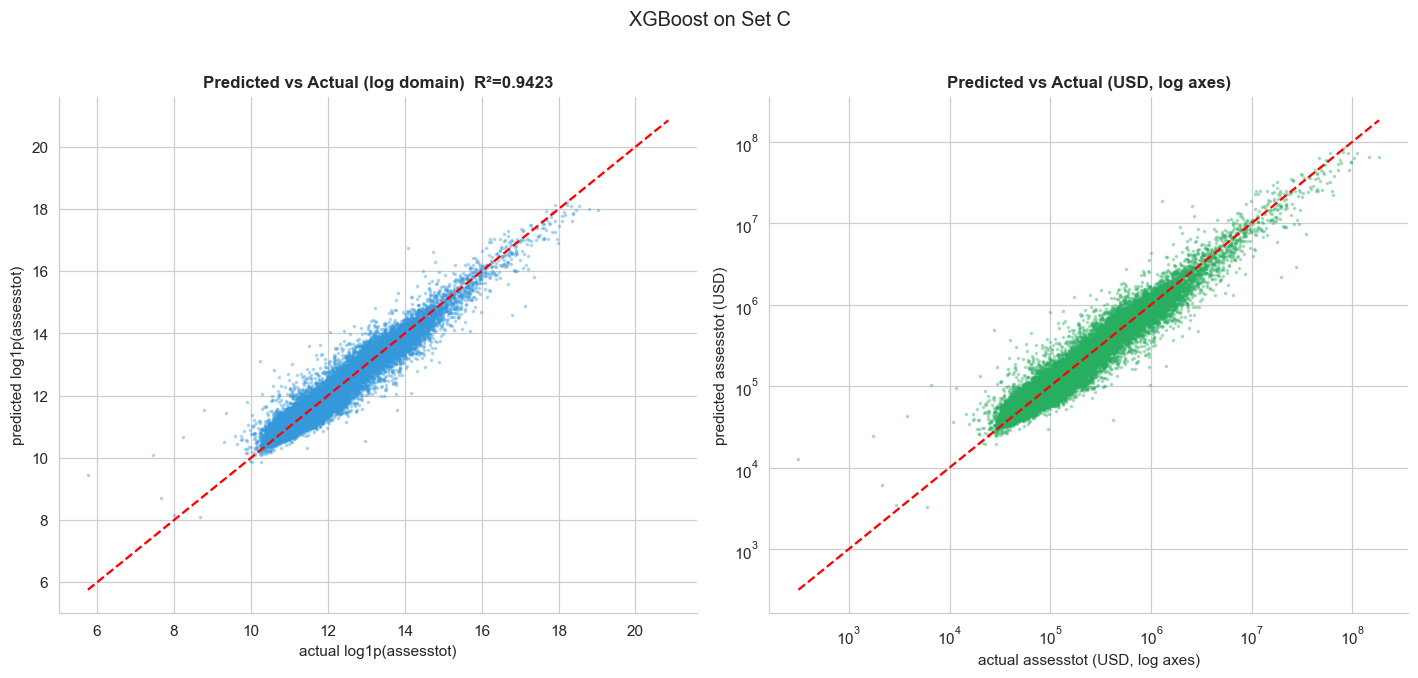

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
rng = np.random.default_rng(seed=RANDOM_SEED)
sample_idx = rng.choice(df.index, size=40_000, replace=False)
s = df.loc[sample_idx]

# Log domain
axes[0].scatter(s['log_assesstot'], s['log_pred'], s=2, alpha=0.3, color='#3498db')
lims = [min(y.min(), oof_pred.min()), max(y.max(), oof_pred.max())]
axes[0].plot(lims, lims, 'r--', linewidth=1.5)
axes[0].set_xlabel('actual log1p(assesstot)'); axes[0].set_ylabel('predicted log1p(assesstot)')
axes[0].set_title(f'Predicted vs Actual (log domain)  R²={r2_score(y, oof_pred):.4f}', fontsize=11, fontweight='bold')

# Linear domain (log axes)
axes[1].scatter(s['assesstot'], s['pred_assesstot'], s=2, alpha=0.3, color='#27ae60')
axes[1].set_xscale('log'); axes[1].set_yscale('log')
lims_lin = [s['assesstot'].min(), s['assesstot'].max()]
axes[1].plot(lims_lin, lims_lin, 'r--', linewidth=1.5)
axes[1].set_xlabel('actual assesstot (USD, log axes)'); axes[1].set_ylabel('predicted assesstot (USD)')
axes[1].set_title('Predicted vs Actual (USD, log axes)', fontsize=11, fontweight='bold')

fig.suptitle(f'{best_model_name} on Set {best_set_name}', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(FIGURE_DIR / '06_predicted_vs_actual.png')
plt.show()

### 11.2 Geographic residual map

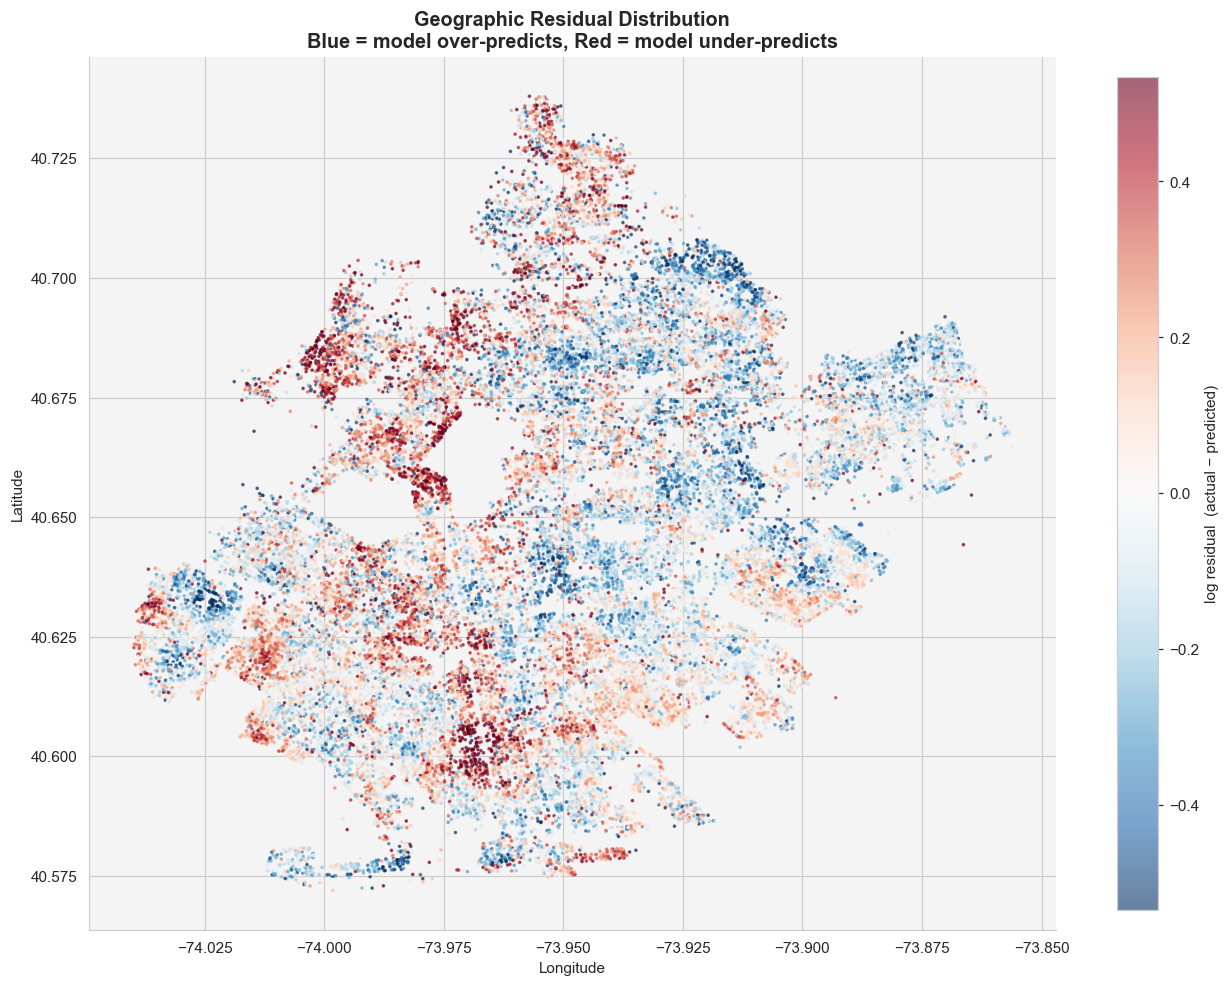

In [22]:
fig, ax = plt.subplots(figsize=(12, 10))
sample = df.loc[sample_idx]

v = np.percentile(np.abs(df['log_residual']), 95)
sc = ax.scatter(sample['longitude'], sample['latitude'],
                c=sample['log_residual'], cmap='RdBu_r',
                s=2, alpha=0.6, vmin=-v, vmax=v)
plt.colorbar(sc, ax=ax, label='log residual  (actual − predicted)', shrink=0.78)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Geographic Residual Distribution\nBlue = model over-predicts, Red = model under-predicts',
             fontsize=13, fontweight='bold')
ax.set_aspect('equal'); ax.set_facecolor('#f4f4f4')
plt.tight_layout()
plt.savefig(FIGURE_DIR / '06_residuals_geographic.png')
plt.show()

---

## Notebook 06 Summary

**Ablation completed:** 9 model × feature set evaluations (3 model families × 3 sets) under spatial CV.

**Key outputs:**
- `outputs/models/best_regression_model.joblib` — for SHAP analysis in Notebook 07
- `outputs/models/ablation_results.joblib` — full table
- `outputs/figures/regression/06_*.png` — ablation chart, predicted-vs-actual, residual map

**Proceed to `07_explainability.ipynb`** — SHAP analysis on the best model: which features drive the predictions, and is the subway-vs-amenity confounding from Notebook 04 actually disentangled by the model?